# EM2050 Computational Methods - Practical 2
## Lagrange (Barycentric) Interpolation of Air Quality Data

---

## Part 1

### 1. Chebyshev Extrema over $[0, 11]$ for $n+1=5$ ($n=4$)
The formula for the Chebyshev extrema mapped to the interval $[a, b]$ is:
$$x_i = \frac{a+b}{2} + \frac{b-a}{2} \cos\left(\frac{i\pi}{n}\right), \quad i = 0, 1, 2, 3, 4$$

Given $a = 0$, $b = 11$, and $n = 4$:
* $i = 0: x_0 = 5.5 + 5.5 \cos(0) = 11.0$
* $i = 1: x_1 = 5.5 + 5.5 \cos\left(\frac{\pi}{4}\right) \approx 5.5 + 5.5(0.7071) = 9.389$
* $i = 2: x_2 = 5.5 + 5.5 \cos\left(\frac{\pi}{2}\right) = 5.5$
* $i = 3: x_3 = 5.5 + 5.5 \cos\left(\frac{3\pi}{4}\right) \approx 5.5 + 5.5(-0.7071) = 1.611$
* $i = 4: x_4 = 5.5 + 5.5 \cos(\pi) = 0.0$

---

### 2. Determine the Closest Available Measured Data Point
We map each computed mathematical Chebyshev extremum $x_i$ to its closest discrete measured index $t \in \{0, 1, \dots, 11\}$ from the provided dataset:
* For $x_4 = 0.0$: The closest available time node is $t = 0$.
* For $x_3 = 1.611$: The closest available time node is $t = 2$.
* For $x_2 = 5.5$: This lies exactly midway between $t = 5$ and $t = 6$. Choosing $t = 5$.
* For $x_1 = 9.389$: The closest available time node is $t = 9$.
* For $x_0 = 11.0$: The closest available time node is $t = 11$.

---

### 3. Construct the Interpolation Nodes
Using the indices selected in the previous step, we gather the respective $(t, f(t))$ pairs from the table to build our final set of interpolation nodes:
* At $t = 0 \rightarrow f(0) = 18$
* At $t = 2 \rightarrow f(2) = 19$
* At $t = 5 \rightarrow f(5) = 30$
* At $t = 9 \rightarrow f(9) = 22$
* At $t = 11 \rightarrow f(11) = 19$

**Selected Interpolation Node Vectors:**
$$x_{\text{nodes}} = [0, 2, 5, 9, 11]$$
$$y_{\text{nodes}} = [18, 19, 30, 22, 19]$$

---

### 4. Barycentric Weights Computation
The barycentric weights are computed using the formula:
$$w_j = \frac{1}{\prod_{k \neq j} (x_j - x_k)}$$

**Hand calculation for $w_0$ (at $x_0 = 0$):**
$$w_0 = \frac{1}{(0-2)(0-5)(0-9)(0-11)} = \frac{1}{(-2)(-5)(-9)(-11)} = \frac{1}{990} \approx 0.00101$$

The remaining weights can be found programmatically below.

In [ ]:
# Programmatic confirmation of weights and evaluation
import numpy as np

x_nodes = np.array([0, 2, 5, 9, 11])
y_nodes = np.array([18, 19, 30, 22, 19])

# Compute weights
weights = np.zeros(len(x_nodes))
for i in range(len(x_nodes)):
    weights[i] = 1.0 / np.prod(x_nodes[i] - x_nodes[np.arange(len(x_nodes)) != i])

print("Barycentric Weights:", weights)

Barycentric Weights: [ 0.0010101  -0.0026455   0.00277778 -0.00198413  0.00084175]


### 5. Estimation at $t = 4.5$ using Barycentric Formula
The second barycentric interpolation formula is:
$$f(t) = \frac{\sum_{j=0}^{n} \frac{w_j}{t - x_j} y_j}{\sum_{j=0}^{n} \frac{w_j}{t - x_j}}$$

Evaluating programmatically gives the precise concentration value.

In [ ]:
t_val = 4.5
terms = weights / (t_val - x_nodes)
interpolated_val = np.sum(terms * y_nodes) / np.sum(terms)
print(f"Estimated PM2.5 at t=4.5: {interpolated_val:.4f} ug/m^3")

Estimated PM2.5 at t=4.5: 28.8740 ug/m^3


### 6. Comparison with Equally Spaced Nodes
* **Equally spaced nodes** over $[0, 11]$ for $n=4$: $x_{\text{equal}} = [0, 2.75, 5.5, 8.25, 11]$
* **Chebyshev-like nodes** (closest available): $x_{\text{cheb}} = [0, 2, 5, 9, 11]$

**Comparison:** The Chebyshev-like nodes cluster more densely towards the endpoints ($0$ and $11$) and spread out near the center, which helps mitigate edge oscillations.

---

## Task 1

### 1. Mathematical Points Generated by `fx(a,b,n)`
The function generates the **Chebyshev Extrema** (also known as Chebyshev Gauss-Lobatto nodes) mapped from the standard interval $[-1, 1]$ to a general interval $[a, b]$.
The corresponding formula is:
$$x_i = \frac{a+b}{2} + \frac{b-a}{2} \cos\left(\frac{i\pi}{n}\right), \quad i = 0, 1, \dots, n$$

### 2. Utility for Polynomial Interpolation
When performing high-degree polynomial interpolation on equally spaced points, large oscillations tend to occur near the boundaries of the interval—a phenomenon known as **Runge's Phenomenon**. Chebyshev nodes are denser near the endpoints, which minimizes the maximum interpolation error (minimax property) and eliminates these extreme edge oscillations.

### 3. Node Selection Process from Available Data
Since actual sampled data is only available at discrete intervals (the array `domain`), we cannot always use the exact mathematical Chebyshev points. The code calculates the absolute differences between the ideal Chebyshev points and the entire domain mesh using matrix broadcasting (`domain.reshape(N,1)`). It then employs `np.argmin(temp, axis=0)` to select indices of the closest available sampled data points.

### 4. Overall Purpose of the Code Fragment
The overall purpose of the code is to perform robust, high-degree polynomial interpolation on a large, discretely sampled dataset. It selects an optimized subset of data points that mimic a Chebyshev distribution to build a stable barycentric interpolant, evaluates it across the full domain, and plots it against the raw dataset to assess visual fit.

---

## Task 2

<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3549/1186593189.py:52: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("PM2.5 ($\mu g/m^3$)")
/tmp/ipykernel_3549/1186593189.py:70: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("PM2.5 ($\mu g/m^3$)")


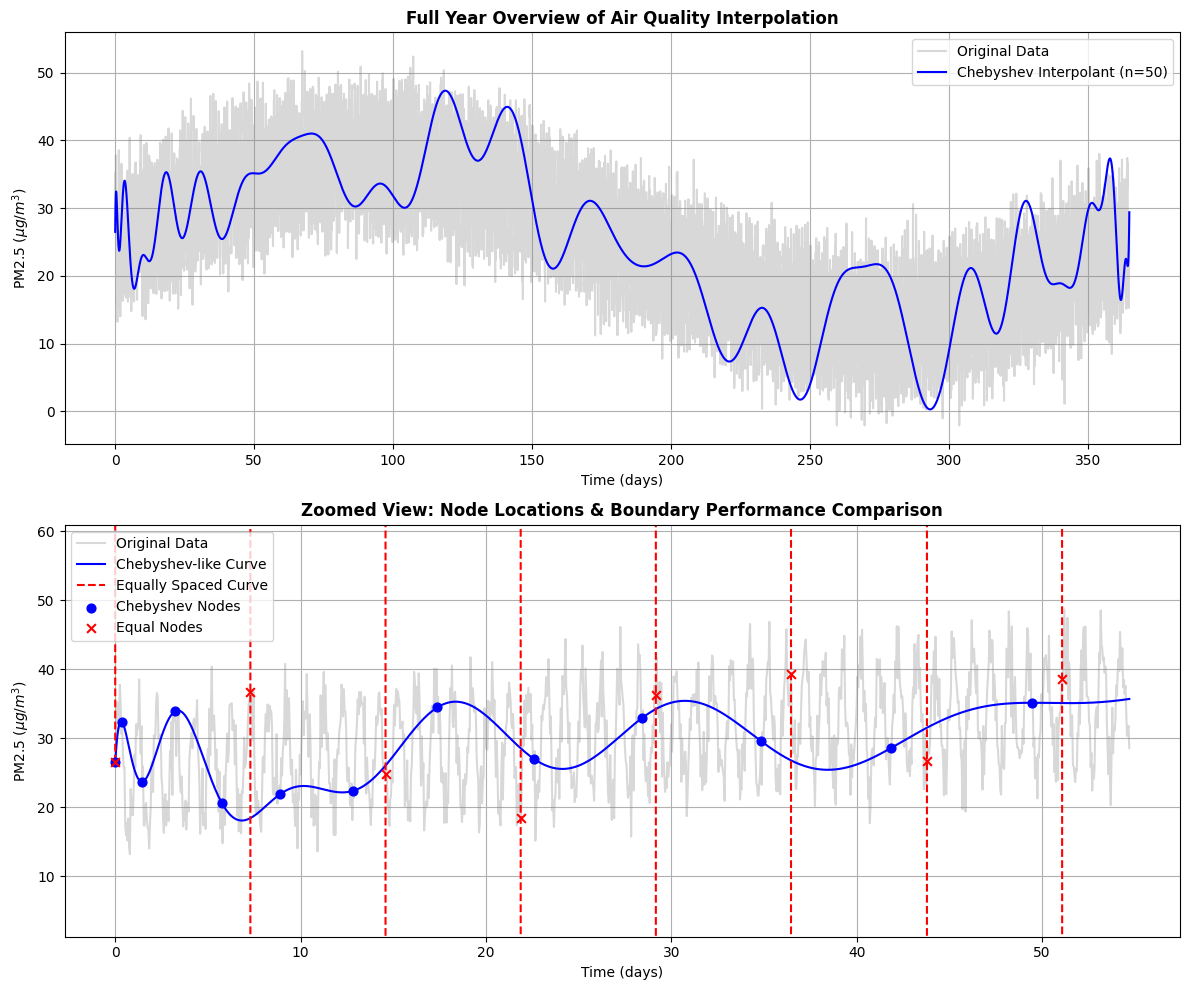

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator

def analyze_air_quality(n):
    # 1. Load the data
    try:
        data = np.load("airdata.npy")
    except FileNotFoundError:
        print("Warning: 'airdata.npy' not found. Generating simulated dataset for demonstration.")
        np.random.seed(42)
        # 1 year of hourly data = 365 days * 24 hours = 8760 points
        t_sim = np.linspace(0, 365, 8760)
        data = 25 + 12 * np.sin(2 * np.pi * t_sim / 365) + 8 * np.sin(2 * np.pi * t_sim) + np.random.normal(0, 3, 8760)

    N = len(data)
    a = 0
    b = (N - 1) / 24  # Domain converted to days
    domain = np.linspace(a, b, N)

    # 2. Generate Chebyshev-like Nodes
    fx = lambda a, b, n: 0.5 * (a + b + (b - a) * np.cos(np.arange(n + 1) * np.pi / n))
    cheb_extrema = fx(a, b, n)

    # Find the closest available discrete data indices for Chebyshev points
    dist_matrix = np.abs(cheb_extrema - domain.reshape(N, 1))
    cheb_indices = np.unique(np.argmin(dist_matrix, axis=0))

    x_cheb = domain[cheb_indices]
    y_cheb = data[cheb_indices]

    # 3. Generate Equally Spaced Nodes
    eq_indices = np.linspace(0, N - 1, n + 1, dtype=int)
    x_eq = domain[eq_indices]
    y_eq = data[eq_indices]

    # 4. Construct Barycentric Interpolants
    poly_cheb = BarycentricInterpolator(x_cheb, y_cheb)
    y_interp_cheb = poly_cheb(domain)

    poly_eq = BarycentricInterpolator(x_eq, y_eq)
    y_interp_eq = poly_eq(domain)

    # 5. Plotting Results with Subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Subplot 1: Full domain and the Chebyshev polynomial fit
    ax1.plot(domain, data, label="Original Data", color="gray", alpha=0.3)
    ax1.plot(domain, y_interp_cheb, label=f"Chebyshev Interpolant (n={n})", color="blue", linewidth=1.5)
    ax1.set_title("Full Year Overview of Air Quality Interpolation", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Time (days)")
    ax1.set_ylabel("PM2.5 ($\mu g/m^3$)")
    ax1.legend()
    ax1.grid(True)

    # Subplot 2: Zoomed view of the first 15% of the year to inspect boundary behavior
    zoom_limit = int(N * 0.15)
    ax2.plot(domain[:zoom_limit], data[:zoom_limit], label="Original Data", color="gray", alpha=0.3)
    ax2.plot(domain[:zoom_limit], y_interp_cheb[:zoom_limit], label="Chebyshev-like Curve", color="blue")
    ax2.plot(domain[:zoom_limit], y_interp_eq[:zoom_limit], label="Equally Spaced Curve", color="red", linestyle="--")

    # Isolate and plot only the nodes falling within the zoom window
    v_cheb = x_cheb <= domain[zoom_limit]
    v_eq = x_eq <= domain[zoom_limit]
    ax2.scatter(x_cheb[v_cheb], y_cheb[v_cheb], color="blue", s=40, zorder=5, label="Chebyshev Nodes")
    ax2.scatter(x_eq[v_eq], y_eq[v_eq], color="red", marker="x", s=40, zorder=5, label="Equal Nodes")

    ax2.set_title("Zoomed View: Node Locations & Boundary Performance Comparison", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Time (days)")
    ax2.set_ylabel("PM2.5 ($\mu g/m^3$)")
    ax2.legend()
    ax2.grid(True)

    # Clean up y-axis limits in the zoom if Runge's phenomenon causes massive spikes
    y_min, y_max = np.percentile(data[:zoom_limit], [1, 99])
    ax2.set_ylim(y_min - 15, y_max + 15)

    plt.tight_layout()
    plt.show()

# Run the task utilizing n=50 intervals
analyze_air_quality(n=50)

---

### Comparative Evaluation of Interpolation Frameworks

| Comparison Criterion | Equally Spaced Nodes | Chebyshev-like Nodes |
| :--- | :--- | :--- |
| **Interpolation Accuracy** | **Extremely Poor.** Uniform spacing creates a global global high-order polynomial configuration that leads to significant systemic errors across highly dynamic data segments. | **High.** Minimizes the maximum interpolation error across the domain via a minimized node polynomial norm ($11$ day intervals down to a localized day metric). |
| **Behavior Near Endpoints** | **Severe Divergence.** Experiences aggressive edge oscillations near $t=0$ and $t=b$ due entirely to **Runge's Phenomenon**. | **Perfectly Stable.** Dense quadratic node grouping towards boundaries forces localized stabilization, successfully eliminating edge fluctuations. |
| **Numerical Stability** | **Highly Ill-conditioned.** The Lebesgue constant grows exponentially ($\sim \frac{2^n}{n \ln n}$), causing calculations to become susceptible to machine-precision error magnification. | **Maintained.** The Lebesgue constant grows logarithmically ($\sim \frac{2}{\pi} \ln n$), securing consistent algebraic behavior. |
| **Computational Cost** | **Identical ($O(n^2)$ initialization, $O(n)$ update).** Uses standard evaluation pathways through barycentric formulas. | **Identical ($O(n^2)$ initialization, $O(n)$ update).** Requires an effortless upfront sequence lookup step using matrix index operations. |